In [1]:
import pandas as pd
import seaborn as sns 

house_data = pd.read_csv(r"C:\Users\victus\OneDrive\Desktop\prime-class\HousePricePrediction.csv")


In [2]:
house_data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [3]:
house_data.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

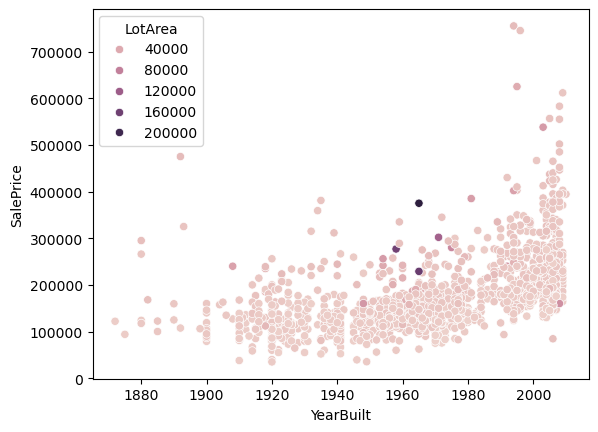

In [4]:
sns.scatterplot(x=house_data["YearBuilt"],y=house_data["SalePrice"],hue=house_data["LotArea"])

In [22]:
from sklearn.model_selection import train_test_split

X = house_data.drop(columns=["SalePrice"])
y = house_data["SalePrice"]


# 2. Encode categorical features
X = pd.get_dummies(X,drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.dtypes)

Id                       int64
MSSubClass               int64
LotArea                  int64
OverallCond              int64
YearBuilt                int64
YearRemodAdd             int64
BsmtFinSF2             float64
TotalBsmtSF            float64
MSZoning_FV               bool
MSZoning_RH               bool
MSZoning_RL               bool
MSZoning_RM               bool
LotConfig_CulDSac         bool
LotConfig_FR2             bool
LotConfig_FR3             bool
LotConfig_Inside          bool
BldgType_2fmCon           bool
BldgType_Duplex           bool
BldgType_Twnhs            bool
BldgType_TwnhsE           bool
Exterior1st_AsphShn       bool
Exterior1st_BrkComm       bool
Exterior1st_BrkFace       bool
Exterior1st_CBlock        bool
Exterior1st_CemntBd       bool
Exterior1st_HdBoard       bool
Exterior1st_ImStucc       bool
Exterior1st_MetalSd       bool
Exterior1st_Plywood       bool
Exterior1st_Stone         bool
Exterior1st_Stucco        bool
Exterior1st_VinylSd       bool
Exterior

In [23]:
# Train model
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred 

array([168733.00189055, 243223.76121104, 114785.4122782 , 157880.21908253,
       254517.60086045, 156703.57888498, 178379.56166675, 127064.11121206,
       133197.4188594 , 149331.19082236, 131000.75218361, 122815.20502721,
        79738.39227967, 239339.94776738, 218129.44955194, 177551.1420249 ,
       218101.29975088, 178803.12616051, 135322.80805372, 233339.70771398,
       163212.5949586 , 219590.49747873, 202612.80166674, 154541.464804  ,
       224316.14395911, 167384.05651946, 228422.20457254, 110932.01963278,
       215243.13926239, 205067.00490291, 115672.66061879, 231708.53736396,
       224244.0047091 , 129036.96376607, 251253.52486046, 140922.92968161,
       170428.17798619, 217706.51759572, 254810.74430391,  78172.67334397,
       119177.72918109, 218351.79277334, 125276.92523566, 291207.78191568,
       141515.57653548, 104779.22150903, 127608.97846474, 131336.69938212,
       320741.92793949, 146047.68650293, 111720.04894557, 193398.07005701,
       123511.08279432, 2

In [26]:
y_test

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
479      89471.0
1361    260000.0
802     189000.0
651     108000.0
722     124500.0
Name: SalePrice, Length: 292, dtype: float64

In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 score:",r2)


R2 score: 0.6196387511449775
